<a href="https://colab.research.google.com/github/BahruzHuseynov/Portfolio/blob/main/DL2_Deep_Learning_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning with PyTorch - (http://pytorch.org/docs)
### Eli Stevens, Luca Antiga, Thomas Viehmann

PyTorch cheat sheet: https://www.learnpytorch.io/pytorch_cheatsheet/ <br>

Github: https://github.com/deep-learning-with-pytorch/dlwpt-code

- Part 1 - Core PyTorch - Chapter 1-8
- Part 2 - Learning from images - Chapter 9-14
- Part 3 - Deployment - Chapter 15

# Chapter 1 -  Introducing deep learning and the PyTorch library

# Chapter 3 - It starts with a tensor

### 3.1 The world as floating-point numbers

### 3.2 Tensors: Multidimensional arrays

In [1]:
# Importing libraries
import torch

In [2]:
# Python lists
a = [1.0, 2.0, 3.0]
print(a)
print(a[0])
print(a[-1])

[1.0, 2.0, 3.0]
1.0
3.0


In [3]:
t = torch.tensor(a)
t

tensor([1., 2., 3.])

In [6]:
# Ones
print(torch.ones(3))
print("-------------------------------")
print(torch.ones((3,2)))
print("-------------------------------")
print(torch.zeros((2,1)))
print("-------------------------------")
print(torch.zeros(5))

tensor([1., 1., 1.])
-------------------------------
tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])
-------------------------------
tensor([[0.],
        [0.]])
-------------------------------
tensor([0., 0., 0., 0., 0.])


In [7]:
a = [[4.0, 1.0], [2.0, 3.0], [5.0, 2.0]]
t = torch.tensor(a)
t[0]

tensor([4., 1.])

In [21]:
print(t.max())
print(t.min())
print(t.mean())
print(t.argmax())

tensor(5.)
tensor(1.)
tensor(2.8333)
tensor(4)


### 3.3 Indexing tensors

In [8]:
lst = list(range(6))
print(lst[:])
print(lst[:3])
print(lst[:-1])
print(lst[2:])

[0, 1, 2, 3, 4, 5]
[0, 1, 2]
[0, 1, 2, 3, 4]
[2, 3, 4, 5]


In [14]:
# Slicing and indexing in PyTorch uses both Python list methods and Numpy methods
print(t)
print("------------------------")
print(t[1:,1:])
print("------------------------")
print(t[1:][1:])
print("------------------------")
print(t[:2, 1])
print("------------------------")
print(t[None]) # it works like 'unsqueeze'

tensor([[4., 1.],
        [2., 3.],
        [5., 2.]])
------------------------
tensor([[3.],
        [2.]])
------------------------
tensor([[5., 2.]])
------------------------
tensor([1., 3.])
------------------------
tensor([[[4., 1.],
         [2., 3.],
         [5., 2.]]])


### 3.4 Named tensors

<h4> The default tensor shape convention for image data in TensorFlow is (batch_size, height, width, channels), whereas in PyTorch, it is (batch_size, channels, height, width) </h4>

In [15]:
img_t = torch.randn(3, 5, 5)  # shape [channels, rows, columns]
weights = torch.tensor([0.2126, 0.7152, 0.0722])
batch_t = torch.randn(2, 3, 5, 5) # shape [batch, channels, rows, columns]

In [16]:
img_gray_naive = img_t.mean(-3)
batch_gray_naive = batch_t.mean(-3)
img_gray_naive.shape, batch_gray_naive.shape

(torch.Size([5, 5]), torch.Size([2, 5, 5]))

In [18]:
img_t

tensor([[[-0.8327, -0.2283, -1.4989,  0.9413,  1.0011],
         [ 1.3505,  0.4212, -1.3755,  0.9733,  0.8840],
         [-0.8117,  0.6609,  1.0841, -1.2714, -0.4861],
         [-0.1576,  1.3072, -1.0689, -2.5104, -1.4007],
         [-0.7442, -0.5482,  0.8654, -0.9758,  0.0203]],

        [[-0.8180, -0.8242, -0.0687,  0.3517,  1.1452],
         [-1.3425, -1.5677, -1.4445,  0.6123, -0.8099],
         [-1.0328, -0.6340,  1.8769,  2.1042, -0.7889],
         [-1.0226,  0.5469,  0.4874,  1.1356,  1.0714],
         [-0.3543, -0.2789, -1.0379, -1.7149,  0.8973]],

        [[ 1.0610, -1.0827,  1.0507,  1.5754,  1.6806],
         [-0.2313, -1.3158, -0.9918, -0.6650,  0.1529],
         [-2.2333, -0.1684, -0.8522, -0.8693, -0.2105],
         [-0.8502,  0.0334,  1.0625,  0.1478,  0.6806],
         [ 0.9135, -1.8334,  0.4664, -0.2604,  0.8740]]])

In [22]:
img_gray_naive # (-0.8327 - 0.8180 + 1.0610) / 3 = -0.1966

tensor([[-0.1966, -0.7117, -0.1723,  0.9561,  1.2756],
        [-0.0744, -0.8208, -1.2706,  0.3068,  0.0757],
        [-1.3593, -0.0472,  0.7029, -0.0122, -0.4952],
        [-0.6768,  0.6292,  0.1604, -0.4090,  0.1171],
        [-0.0617, -0.8868,  0.0980, -0.9837,  0.5972]])

### 3.5 Tensor element types

<h4> Comparing Python lists with Numpy or PyTorch tensors. In Python: </h4>

- Numbers are objects
- Lists are sequential collections of objects and there are no operations defined to sum or multiply the vectors or matrices.
- Python interpreter is slow compared to optimized or compiled code.

<h4> For these reasons, data science libraries rely on NumPy or introduce dedicated data
structures like PyTorch tensors, which provide efficient low-level implementations of
numerical data structures. </h4>

In [32]:
# dtype
t = torch.tensor([[2, 3], [4, 10]], dtype = torch.float32)
print(t)
print(t.dtype)
print(t.shape)

tensor([[ 2.,  3.],
        [ 4., 10.]])
torch.float32
torch.Size([2, 2])


In [33]:
t*3

tensor([[ 6.,  9.],
        [12., 30.]])

<h4> Numeric types in PyTorch: </h4>

- torch.float32 or torch.float: 32-bit floating-point
- torch.float64 or torch.double: 64-bit, double-precision floating-point
- torch.float16 or torch.half: 16-bit, half-precision floating-point
- torch.int8: signed 8-bit integers
- torch.uint8: unsigned 8-bit integers
- torch.int16 or torch.short: signed 16-bit integers
- torch.int32 or torch.int: signed 32-bit integers
- torch.int64 or torch.long: signed 64-bit integers
- torch.bool: Boolean

In [24]:
short_points = torch.tensor([[1, 2], [3, 4]], dtype=torch.short)
short_points

tensor([[1, 2],
        [3, 4]], dtype=torch.int16)

In [27]:
torch.rand(5, dtype=torch.double)

tensor([0.1121, 0.2755, 0.1477, 0.0494, 0.6520], dtype=torch.float64)

In [31]:
# Pandas features
a = torch.rand((3,3))
print(a > 0.5) # a = a > 0.5

tensor([[False, False,  True],
        [ True, False,  True],
        [False, False,  True]])


### 3.6 The Tensor API

In [37]:
a = torch.tensor([[2,4,3],[10,-4,2]])
a_t = torch.transpose(a, 0, 1)

In [38]:
print(a)
print("---------------------------")
print(a_t)

tensor([[ 2,  4,  3],
        [10, -4,  2]])
---------------------------
tensor([[ 2, 10],
        [ 4, -4],
        [ 3,  2]])


In [39]:
a.shape, a_t.shape

(torch.Size([2, 3]), torch.Size([3, 2]))

# Chapter 4 - Real-world data representation using tensors

#### In the previous chapter, we learned that tensors are fundamental in PyTorch, serving as the building blocks for data. Neural networks operate on tensors, and all parameters in a neural network, such as weights and biases, are tensors. Proficiency in tensor operations is crucial for effective use of PyTorch tools. This chapter focuses on representing diverse data types as tensors, covering loading data, understanding data structures, and preparing for neural network training. Each section describes a specific data type and includes a dataset, building progressively for hands-on learning.

### 4.1 Working with Images

#### The introduction of convolutional neural networks (CNNs) has transformed computer vision, enabling end-to-end training for image-based systems. Previously complex problems now achieve unprecedented performance levels by training networks with paired input-and-output examples. To participate in this revolution, it's essential to load images from common formats and transform the data into PyTorch-compatible tensor representations.

#### Images are grids of scalars with height and width, representing pixels. A single scalar per pixel results in grayscale images, while multiple scalars may represent colors or features like depth. Scalars, often encoded as 8-bit integers in consumer cameras, can have higher precision (e.g., 12-bit or 16-bit) in medical and industrial applications, offering a broader range and increased sensitivity for properties such as bone density or temperature.

<h4> Mainly used image format is RGB which contains the intensity of red, green and blue.</h4>

<img src = "https://cdn.britannica.com/89/234589-050-0E6E9D4B/color-wheel-additive.jpg">

In [40]:
# Loading an image file
import imageio

img_arr = imageio.imread("https://webneel.com/wallpaper/sites/default/files/images/08-2018/3-nature-wallpaper-mountain.jpg")
img_arr.shape

<ipython-input-40-5befece7375b>:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_arr = imageio.imread("https://webneel.com/wallpaper/sites/default/files/images/08-2018/3-nature-wallpaper-mountain.jpg")


(1008, 1600, 3)

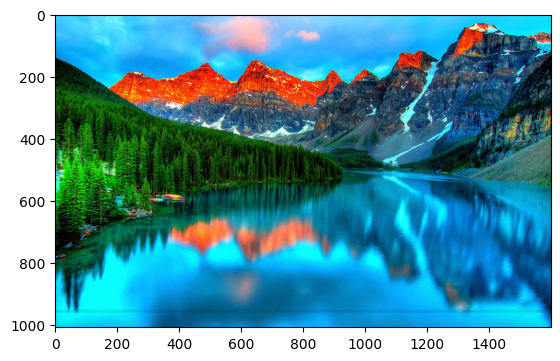

In [42]:
import matplotlib.pyplot as plt

plt.imshow(img_arr)

In [43]:
# Changing the layout
img = torch.from_numpy(img_arr) # converts it to tensor
out = img.permute(2,0,1)

In [44]:
out.shape # As PyTorch works in the structure of (channels, height and width)
# C x H x W

torch.Size([3, 1008, 1600])

<h4> 'out' variable uses the same underlying storage as 'img' variable and only plays with the size and stride information at the tensor level. This is convenient because the operation is very cheap; but just as a heads-up: <b><i> changing a pixel in 'img' will lead to a change in 'out' </i></b> </h4>

In [45]:
# Tensor with a batch size (New format: N x C x H x W)
batch_size = 3
entire = torch.zeros(batch_size, 3, 256, 256, dtype=torch.uint8)
entire.shape

torch.Size([3, 3, 256, 256])

This indicates that our batch will consist of three RGB images 256 pixels in height and 256 pixels in width.

In [118]:
# Data Normalization
entire = entire.float() # Without conversion, error will occur
entire /= 255

In [120]:
entire.shape

torch.Size([3, 3, 256, 256])

In [123]:
entire[:, 0].shape # Takes the first batch

torch.Size([3, 256, 256])

In [124]:
# Another way to normalize data (mean = 0, std = 1)
n_channels = entire.shape[1]
for c in range(n_channels):
  mean = torch.mean(entire[:, c])
  std = torch.mean(entire[:, c])
  entire[:, c] = (entire[:, c] - mean) / std

### 4.2 3D images: Volumetric data

#### In 4.1 section, 2D images are the main thing to concentrate on, however sometimes it is needy to focus on videos (sequences of images). For example, in CT (computed tomogrophy) scans.

<img src = "https://fortworthent.net/wp-content/uploads/2014/08/In-Office-CT-Scan-sinuses.jpg">

<br>

<h4> Part 2 (From chapter 9 to 14) will be devoted to tackle a medical imaging problem in the real world. So we won’t go into the details of medical-imaging data formats. For now, it suffices to say that there’s no fundamental difference between a tensor storing volumetric data versus image data. We just have an extra dimension, <i> depth </i> , after the channel dimension, leading to a 5D tensor of shape N × C × D × H × W  </h4>